<a href="https://colab.research.google.com/github/faajr/mbg_sentimen/blob/main/MBG_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sentiment Analysis - Program Makan Bergizi Gratis (MBG)
Melakukan sentimen analisis dari komentar YouTube mengenai isu **Makan Bergizi Gratis**. Langkah-langkahnya meliputi scraping data, preprocessing teks, pelabelan menggunakan **IndoBERT**, Exploratory Data Analysis (EDA), pemodelan Machine Learning (TF-IDF, Naive Bayes, Random Forest), dan evaluasi model.


## 1. Instalasi Library yang Dibutuhkan
Menggunakan beberapa library eksternal seperti `youtube-comment-downloader` untuk scraping tanpa API Key, `Sastrawi` untuk stemming bahasa Indonesia, dan `transformers` untuk IndoBERT.


In [ ]:
!pip install youtube-comment-downloader
!pip install Sastrawi
!pip install transformers torch
!pip install wordcloud matplotlib seaborn pandas scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.5/300.5 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 5.1 MB/s eta 0:00:00


## 2. Scraping Data Komentar YouTube
Video yang akan digunakan: https://www.youtube.com/watch?v=SVI8xheP-j4


In [ ]:
import pandas as pd
import itertools
from youtube_comment_downloader import YoutubeCommentDownloader, SORT_BY_RECENT

print('Memulai proses scraping data...')
video_url = 'https://www.youtube.com/watch?v=SVI8xheP-j4'
downloader = YoutubeCommentDownloader()
comments = downloader.get_comments_from_url(video_url, sort_by=SORT_BY_RECENT)

results = []
for comment in itertools.islice(comments, 6000):
    results.append(comment['text'])

df = pd.DataFrame(results, columns=['text'])
print(f'Berhasil mengambil {len(df)} komentar.')
df.head()

Memulai proses scraping data...
Berhasil mengambil 6000 komentar.


,text
0,Bagaimana pendapat kamu tentang MBG? Tulis pan...
1,"gratis dari mana ,itu uang rakyat tapi masih..."
2,Yg perlu dikasi MBG terbatas pd anak2 miskin n...
3,KALO PRABOWO MASIH TERUS MEMAKSAKAN DIRI UTK M...
4,Yah menyetujui di ajarin naik abis berapa aja ...


## 3. Data Understanding (EDA Awal)
Mengecek jumlah data, missing value, dan data duplikat.


In [ ]:
print("Info Dataset:")
print(df.info())
print("\nJumlah Missing Value:")
print(df.isnull().sum())
print("\nJumlah Data Duplikat:")
print(df.duplicated().sum())

# Membersihkan duplikat dan missing value
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
print(f"\nJumlah data setelah dibersihkan: {len(df)}")

Info Dataset:
<class 'pandas.core.frame.DataFrame'>
Index: 5935 entries, 0 to 5999
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   text          5935 non-null   object
 1   cleaned_text  5935 non-null   object
dtypes: object(2)
memory usage: 139.1+ KB
None

Jumlah Missing Value:
text            0
cleaned_text    0
dtype: int64

Jumlah Data Duplikat:
0

Jumlah data setelah dibersihkan: 5935


## 4. Data Preprocessing
Tahap ini meliputi Case Folding, Cleaning (URL, Mention, Hashtag, Emoji, Number, Punctuation), Stopword Removal, dan Stemming menggunakan `Sastrawi`.


In [ ]:
import re
import string
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

factory_stemmer = StemmerFactory()
stemmer = factory_stemmer.create_stemmer()

factory_stopword = StopWordRemoverFactory()
stopword = factory_stopword.create_stop_word_remover()

def clean_text(text):
    text = str(text).lower() # Case folding
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) # Hapus URL
    text = re.sub(r'@\w+', '', text) # Hapus Mention
    text = re.sub(r'#\w+', '', text) # Hapus Hashtag
    text = re.sub(r'\d+', '', text) # Hapus Angka
    text = text.translate(str.maketrans('', '', string.punctuation)) # Hapus tanda baca
    # Menghapus emoji bisa dengan regex atau library, untuk simpelnya hilangkan karakter non-ascii
    text = text.encode('ascii', 'ignore').decode('ascii')
    text = text.strip()
    return text

def preprocess_text(text):
    cleaned_text = clean_text(text)
    stop_removed = stopword.remove(cleaned_text)
    stemmed_text = stemmer.stem(stop_removed)
    return stemmed_text

print("Proses preprocessing dimulai... Ini akan memakan waktu beberapa menit karena proses stemming.")
df['cleaned_text'] = df['text'].apply(clean_text)
df['preprocessed_text'] = df['cleaned_text'].apply(preprocess_text)

# Hapus data yang menjadi kosong setelah preprocessing
df = df[df['preprocessed_text'].str.strip() != '']
df.reset_index(drop=True, inplace=True)
df.head()

Proses preprocessing dimulai... Ini akan memakan waktu beberapa menit karena proses stemming.


,text,cleaned_text,preprocessed_text
0,Bagaimana pendapat kamu tentang MBG? Tulis pan...,bagaimana pendapat kamu tentang mbg tulis pand...,bagaimana dapat kamu mbg tulis pandang kamu ko...
1,"gratis dari mana ,itu uang rakyat tapi masih...",gratis dari mana itu uang rakyat tapi masih ...,gratis mana uang rakyat masih korup jamaah
2,Yg perlu dikasi MBG terbatas pd anak2 miskin n...,yg perlu dikasi mbg terbatas pd anak miskin n ...,yg perlu kasi mbg batas pd anak miskin n ibu h...
3,KALO PRABOWO MASIH TERUS MEMAKSAKAN DIRI UTK M...,kalo prabowo masih terus memaksakan diri utk m...,kalo prabowo terus paksa diri utk mbg jalan te...
4,Yah menyetujui di ajarin naik abis berapa aja ...,yah menyetujui di ajarin naik abis berapa aja ...,yah tuju ajarin naik abis berapa aja kalau awa...


## 5. Sentiment Labeling Menggunakan IndoBERT
Karena data tidak memiliki label sentimen bawaan, kita akan menggunakan model pra-latih `IndoBERT` yang sudah di-*fine-tune* untuk analisis sentimen berbahasa Indonesia.


In [ ]:
from transformers import pipeline
import tqdm
tqdm.tqdm.pandas()

print("Memuat model IndoBERT...")
# Menggunakan model indonesian-roberta untuk sentimen (Positif, Netral, Negatif)
pretrained_name = "w11wo/indonesian-roberta-base-sentiment-classifier"
nlp = pipeline("sentiment-analysis", model=pretrained_name, truncation=True, max_length=512)

def get_sentiment(text):
    try:
        result = nlp(text)[0]
        label = result['label'].lower()
        if 'pos' in label: return 'Positive'
        elif 'neg' in label: return 'Negative'
        else: return 'Neutral'
    except:
        return 'Neutral'

print("Melakukan pelabelan otomatis... (Tunggu sebentar)")
df['sentiment'] = df['preprocessed_text'].progress_apply(get_sentiment)

df.head()

Memuat model IndoBERT...


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/328 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/1.38M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Melakukan pelabelan otomatis... (Tunggu sebentar)


100%|██████████| 5896/5896 [17:30<00:00,  5.61it/s]
/tmp/ipykernel_486/3992738361.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sentiment'] = df['preprocessed_text'].progress_apply(get_sentiment)


,text,cleaned_text,preprocessed_text,sentiment
0,Bagaimana pendapat kamu tentang MBG? Tulis pan...,bagaimana pendapat kamu tentang mbg tulis pand...,bagaimana dapat kamu mbg tulis pandang kamu ko...,Neutral
1,"gratis dari mana ,itu uang rakyat tapi masih...",gratis dari mana itu uang rakyat tapi masih ...,gratis mana uang rakyat masih korup jamaah,Negative
2,Yg perlu dikasi MBG terbatas pd anak2 miskin n...,yg perlu dikasi mbg terbatas pd anak miskin n ...,yg perlu kasi mbg batas pd anak miskin n ibu h...,Negative
3,KALO PRABOWO MASIH TERUS MEMAKSAKAN DIRI UTK M...,kalo prabowo masih terus memaksakan diri utk m...,kalo prabowo terus paksa diri utk mbg jalan te...,Negative
4,Yah menyetujui di ajarin naik abis berapa aja ...,yah menyetujui di ajarin naik abis berapa aja ...,yah tuju ajarin naik abis berapa aja kalau awa...,Negative


## 6. Exploratory Data Analysis (EDA Lanjutan)
Visualisasi Distribusi Sentimen, WordCloud, dan Top Frequent Words.


/tmp/ipykernel_486/831013437.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=df, palette='viridis')


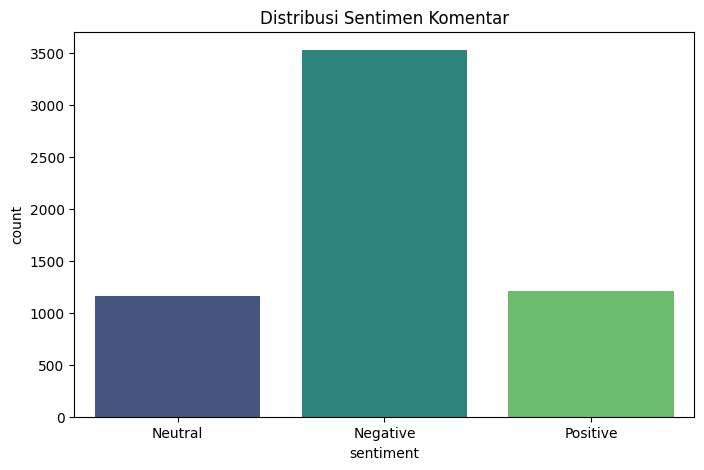

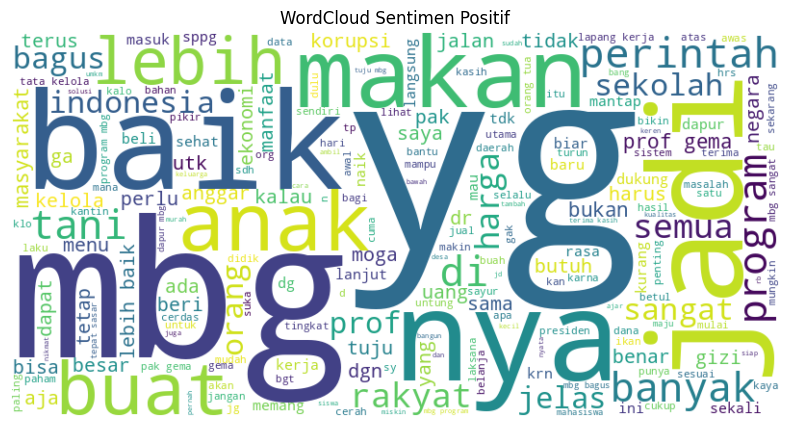

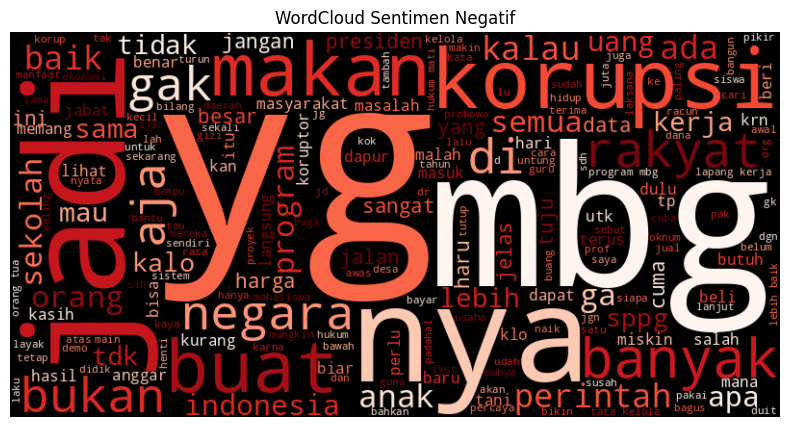

/tmp/ipykernel_486/831013437.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), palette='mako')


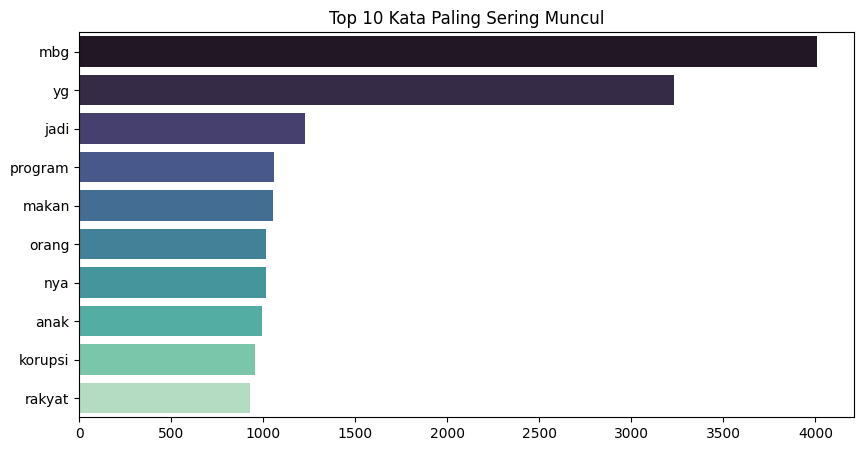

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

# 6.1 Distribusi Sentimen
plt.figure(figsize=(8,5))
sns.countplot(x='sentiment', data=df, palette='viridis')
plt.title('Distribusi Sentimen Komentar')
plt.show()

# 6.2 WordCloud Positive & Negative
pos_text = ' '.join(df[df['sentiment'] == 'Positive']['preprocessed_text'])
neg_text = ' '.join(df[df['sentiment'] == 'Negative']['preprocessed_text'])

if len(pos_text) > 0:
    wordcloud_pos = WordCloud(width=800, height=400, background_color='white').generate(pos_text)
    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud_pos, interpolation='bilinear')
    plt.title('WordCloud Sentimen Positif')
    plt.axis('off')
    plt.show()

if len(neg_text) > 0:
    wordcloud_neg = WordCloud(width=800, height=400, background_color='black', colormap='Reds').generate(neg_text)
    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud_neg, interpolation='bilinear')
    plt.title('WordCloud Sentimen Negatif')
    plt.axis('off')
    plt.show()

# 6.3 Top Frequent Words
all_words = ' '.join(df['preprocessed_text']).split()
word_counts = Counter(all_words)
common_words = word_counts.most_common(10)
words, counts = zip(*common_words)

plt.figure(figsize=(10,5))
sns.barplot(x=list(counts), y=list(words), palette='mako')
plt.title('Top 10 Kata Paling Sering Muncul')
plt.show()

## 7. Feature Engineering
Mengubah teks menjadi representasi vektor menggunakan `TF-IDF Vectorizer`.


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

vectorizer = TfidfVectorizer(ngram_range=(1, 2)) # Menggunakan Unigram dan Bigram
X = vectorizer.fit_transform(df['preprocessed_text'])
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Data Latih: {X_train.shape[0]} baris, Data Uji: {X_test.shape[0]} baris")

Data Latih: 4716 baris, Data Uji: 1180 baris


## 8. Modeling dan Evaluasi
Kita akan melatih model `Naive Bayes` dan `Random Forest`, lalu mengevaluasinya menggunakan Accuracy, Precision, Recall, F1 Score, dan Confusion Matrix.


--- Evaluasi Model Naive Bayes ---
Accuracy  : 0.5915
Precision : 0.5049
Recall    : 0.5915
F1 Score  : 0.4465

Classification Report:
              precision    recall  f1-score   support

    Negative       0.59      1.00      0.74       692
     Neutral       0.00      0.00      0.00       247
    Positive       0.78      0.03      0.06       241

    accuracy                           0.59      1180
   macro avg       0.46      0.34      0.27      1180
weighted avg       0.50      0.59      0.45      1180



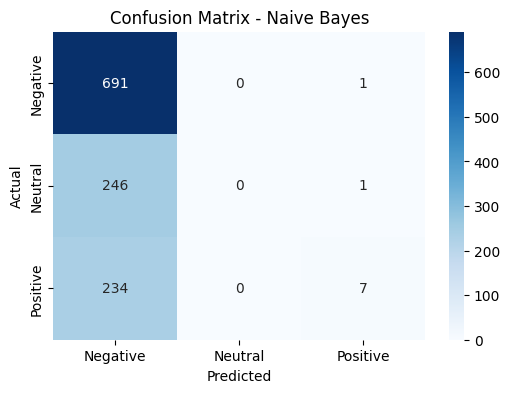

--- Evaluasi Model Random Forest ---
Accuracy  : 0.6754
Precision : 0.6938
Recall    : 0.6754
F1 Score  : 0.6271

Classification Report:
              precision    recall  f1-score   support

    Negative       0.67      0.95      0.78       692
     Neutral       0.67      0.36      0.47       247
    Positive       0.79      0.22      0.34       241

    accuracy                           0.68      1180
   macro avg       0.71      0.51      0.53      1180
weighted avg       0.69      0.68      0.63      1180



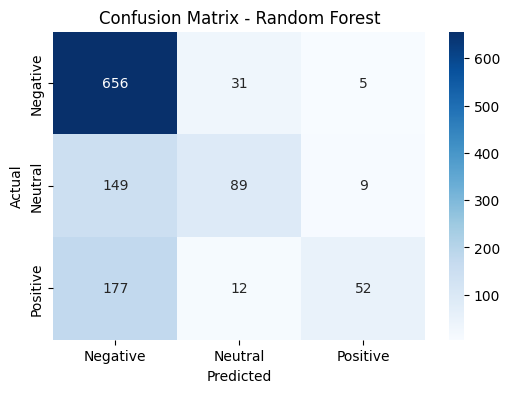

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score

def evaluate_model(model, model_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    print(f"--- Evaluasi Model {model_name} ---")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1 Score  : {f1:.4f}\n")

    print("Classification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    plt.figure(figsize=(6,4))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    return model

# Model 1: Naive Bayes
nb_model = MultinomialNB()
nb_model = evaluate_model(nb_model, "Naive Bayes")

# Model 2: Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model = evaluate_model(rf_model, "Random Forest")

## 9. Menyimpan Model Terbaik
Menggunakan model `Naive Bayes` (biasanya sangat cepat dan cukup handal untuk teks) dan `Random Forest` simpan ke dalam file `.pkl` agar dapat digunakan di Streamlit.


In [ ]:
import pickle

# Disini kita simpan model Random Forest
with open('model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

# Simpan vectorizer juga
with open('vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

print("Model dan Vectorizer berhasil disimpan! (Silakan download file model.pkl dan vectorizer.pkl dari panel Files di sebelah kiri untuk deployment Streamlit)")

Model dan Vectorizer berhasil disimpan! (Silakan download file model.pkl dan vectorizer.pkl dari panel Files di sebelah kiri untuk deployment Streamlit)
